# Task 2: Interpolation

From the analysis we know that returns are approximately stationary, data exhibit no seasonality, weak autocorrelation in returns, strong volatility clustering, and some cross-series correlation.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../Data/processed_data.csv')

# Removing last 200 values
df = df.iloc[:-200]

# If no date column exists, use integer time index
df.index = np.arange(len(df))

assets = [
    "gurkor", "guitars", "slingshots", 
    "stocks", "sugar", "water", "tranquillity"
]

log_prices = np.log(df[assets])

KeyError: "['slingshots'] not in index"

## Data Interpretation

There is some missing values within each time series that needs interpolation.

### Zoomed 50-point internal gaps

The next code cell (after `intervals` is built) draws **one subplot per asset** in a single figure. Only series with **exactly one** internal missing run of **50** points are included; smaller internal holes are ignored.


## Interpolation Models

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor

def interpolate_linear(x):
    """
    Linear interpolation.
    This method simply connects the data points with straight lines.
    """
    return x.interpolate(method="linear", limit_direction="both")


def interpolate_spline(x, order=3):
    """
    Cubic spline interpolation.
    This method is a more sophisticated approach that fits a smooth curve through the data points.
    """
    return x.interpolate(method="spline", order=order, limit_direction="both")


def interpolate_pchip(x):
    """
    Shape-preserving interpolation.
    """
    return x.interpolate(method="pchip", limit_direction="both")

def interpolate_cross_series(log_prices, target, alpha=1.0):
    """
    Cross-series interpolation.
    This method uses the other series to predict the missing values.
    """
    data = log_prices.copy()
    y = data[target]
    
    missing = y.isna()
    observed = ~missing
    
    predictors = [c for c in data.columns if c != target]
    
    # First fill predictors using simple linear interpolation
    X_all = data[predictors].interpolate(method="linear", limit_direction="both")
    
    # Training data: target observed and predictors available
    train_mask = observed & X_all.notna().all(axis=1)
    
    if train_mask.sum() < 50:
        return y.interpolate(method="linear", limit_direction="both")
    
    model = Ridge(alpha=alpha)
    model.fit(X_all.loc[train_mask], y.loc[train_mask])
    
    y_filled = y.copy()
    pred_mask = missing & X_all.notna().all(axis=1)
    y_filled.loc[pred_mask] = model.predict(X_all.loc[pred_mask])
    
    # fallback if anything remains missing
    y_filled = y_filled.interpolate(method="linear", limit_direction="both")
    
    return y_filled

## Validation by Artificial Gap Masking

### Helper functions

In [ ]:


def make_artificial_gaps(series, gap_lengths=[20, 50, 100, 200], n_trials=20, seed=123):
    rng = np.random.default_rng(seed)
    valid_idx = np.where(series.notna())[0]
    
    gaps = []
    n = len(series)
    
    for L in gap_lengths:
        for _ in range(n_trials):
            start = rng.integers(0, n - L)
            block = np.arange(start, start + L)
            
            if series.iloc[block].notna().all():
                gaps.append((start, start + L, L))
    
    return gaps

def evaluate_methods(log_prices, asset, gap_lengths=[20, 50, 100, 200], n_trials=20):
    true_series = log_prices[asset].copy()
    gaps = make_artificial_gaps(true_series, gap_lengths, n_trials)
    
    results = []
    
    for start, end, L in gaps:
        masked = log_prices.copy()
        true_values = masked.loc[start:end-1, asset].copy()
        masked.loc[start:end-1, asset] = np.nan
        
        methods = {
            "linear": interpolate_linear(masked[asset]),
            "spline": interpolate_spline(masked[asset]),
            "pchip": interpolate_pchip(masked[asset]),
            "cross_series_ridge": interpolate_cross_series(masked, asset)
        }
        
        for name, filled in methods.items():
            pred = filled.loc[start:end-1]
            
            mae = mean_absolute_error(true_values, pred)
            rmse = np.sqrt(mean_squared_error(true_values, pred))
            
            results.append({
                "asset": asset,
                "method": name,
                "gap_length": L,
                "start": start,
                "end": end,
                "MAE_log": mae,
                "RMSE_log": rmse
            })
    
    return pd.DataFrame(results)



### Running Validation for all Assets

In [ ]:
all_results = []

for asset in assets:
    res = evaluate_methods(log_prices, asset)
    all_results.append(res)

validation_results = pd.concat(all_results, ignore_index=True)

KeyboardInterrupt: 

### Summary

In [ ]:
summary = (
    validation_results
    .groupby(["asset", "method", "gap_length"])[["MAE_log", "RMSE_log"]]
    .mean()
    .reset_index()
)

summary

,asset,method,gap_length,MAE_log,RMSE_log
0,guitars,cross_series_ridge,20,0.094990,0.098917
1,guitars,cross_series_ridge,50,0.112977,0.120250
2,guitars,cross_series_ridge,100,0.117415,0.125751
3,guitars,cross_series_ridge,200,0.100347,0.111976
4,guitars,linear,20,0.021104,0.024291
...,...,...,...,...,...
107,water,pchip,200,0.016123,0.019220
108,water,spline,20,0.035667,0.036531
109,water,spline,50,0.032872,0.034433
110,water,spline,100,0.047026,0.048536


### Overall Ranking

In [ ]:
overall = (
    validation_results
    .groupby("method")[["MAE_log", "RMSE_log"]]
    .mean()
    .sort_values("RMSE_log")
)

overall

,MAE_log,RMSE_log
method,,
linear,0.028482,0.034036
pchip,0.030072,0.035916
cross_series_ridge,0.078608,0.084789
spline,0.119737,0.125266


# Choose Best Method per Asset

In [ ]:
best_method_per_asset = (
    validation_results
    .groupby(["asset", "method"])["RMSE_log"]
    .mean()
    .reset_index()
    .sort_values(["asset", "RMSE_log"])
    .groupby("asset")
    .first()
)

best_method_per_asset

,method,RMSE_log
asset,,
guitars,linear,0.045070
gurkor,linear,0.011145
slingshots,linear,0.043567
stocks,linear,0.048502
sugar,linear,0.040336
tranquillity,linear,0.039842
water,linear,0.010435


## Fill Actual Missing Values

In [ ]:
def fill_asset(log_prices, asset, method):
    if method == "linear":
        return interpolate_linear(log_prices[asset])
    elif method == "spline":
        return interpolate_spline(log_prices[asset])
    elif method == "pchip":
        return interpolate_pchip(log_prices[asset])
    elif method == "cross_series_ridge":
        return interpolate_cross_series(log_prices, asset)
    else:
        raise ValueError(f"Unknown method: {method}")

log_filled = log_prices.copy()

for asset in assets:
    method = best_method_per_asset.loc[asset, "method"]
    log_filled[asset] = fill_asset(log_prices, asset, method)

df_filled = np.exp(log_filled)

## Estimating Uncertainty

In [ ]:
uncertainty = (
    validation_results
    .groupby(["asset", "method"])["RMSE_log"]
    .mean()
    .reset_index()
)

intervals = {}

for asset in assets:
    method = best_method_per_asset.loc[asset, "method"]
    sigma = uncertainty.query("asset == @asset and method == @method")["RMSE_log"].iloc[0]
    
    mean_log = log_filled[asset]
    
    lower = np.exp(mean_log - 1.96 * sigma)
    upper = np.exp(mean_log + 1.96 * sigma)
    
    intervals[asset] = pd.DataFrame({
        "estimate": np.exp(mean_log),
        "lower_95": lower,
        "upper_95": upper
    })

intervals["gurkor"].head()

,estimate,lower_95,upper_95
0,6.154653,6.021663,6.290580
1,6.189623,6.055877,6.326322
2,6.168641,6.035348,6.304877
3,6.156401,6.023373,6.292367
4,6.124929,5.992581,6.260200


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

INTERNAL_GAP_LEN = 50
ZOOM_PAD = 40


def internal_nan_runs(s: pd.Series):
    """Return (start, end) inclusive positional indices for internal NaN blocks."""
    x = s.isna().to_numpy()
    if not x.any():
        return []
    padded = np.concatenate([[False], x, [False]])
    diff = np.diff(padded.astype(int))
    starts = np.where(diff == 1)[0]
    ends = np.where(diff == -1)[0] - 1
    runs = []
    for a, b in zip(starts, ends):
        if a > 0 and b < len(s) - 1:
            runs.append((a, b))
    return runs


def main_internal_gap_run(s: pd.Series, length: int = INTERNAL_GAP_LEN):
    """The single internal missing stretch of exactly `length` points, or None."""
    candidates = [
        (a, b) for a, b in internal_nan_runs(s)
        if (b - a + 1) == length
    ]
    if len(candidates) != 1:
        return None
    return candidates[0]


def plot_internal_gaps_subplots(pad: int = ZOOM_PAD):
    panels = []
    for asset in assets:
        original = df[asset].astype(float)
        run = main_internal_gap_run(original, INTERNAL_GAP_LEN)
        if run is None:
            continue
        panels.append((asset, original, run))

    if not panels:
        print(
            f"No series with exactly one internal NaN run of length {INTERNAL_GAP_LEN}. "
            "Nothing to plot."
        )
        return

    n = len(panels)
    fig, axes = plt.subplots(
        n, 1, figsize=(12, 3.2 * n), sharex=False, constrained_layout=True
    )
    if n == 1:
        axes = np.array([axes])

    for ax, (asset, original, (a, b)) in zip(axes, panels):
        est = intervals[asset].reindex(original.index)
        filled = est["estimate"]
        lower = est["lower_95"]
        upper = est["upper_95"]

        idx = original.index.to_numpy()
        lo = max(idx.min(), idx[a] - pad)
        hi = min(idx.max(), idx[b] + pad)
        mask = (idx >= lo) & (idx <= hi)

        ax.plot(idx[mask], original.to_numpy()[mask], label="Observed", lw=1.5)
        ax.plot(idx[mask], filled.to_numpy()[mask], label="Filled estimate", lw=1.5)
        ax.fill_between(
            idx[mask],
            lower.to_numpy()[mask],
            upper.to_numpy()[mask],
            alpha=0.2,
            label="95% interval",
        )
        ax.axvspan(idx[a], idx[b], color="gray", alpha=0.15, label="Missing (original)")
        ax.set_title(
            f"{asset}: internal gap [{idx[a]}–{idx[b]}], {idx[b] - idx[a] + 1} points"
        )
        ax.set_ylabel("Price level")
        ax.legend(loc="best", fontsize=8)

    axes[-1].set_xlabel("Index")
    fig.suptitle("50-point internal gaps (zoomed)", fontsize=12, y=1.01)
    plt.show()


plot_internal_gaps_subplots()


## Plotting

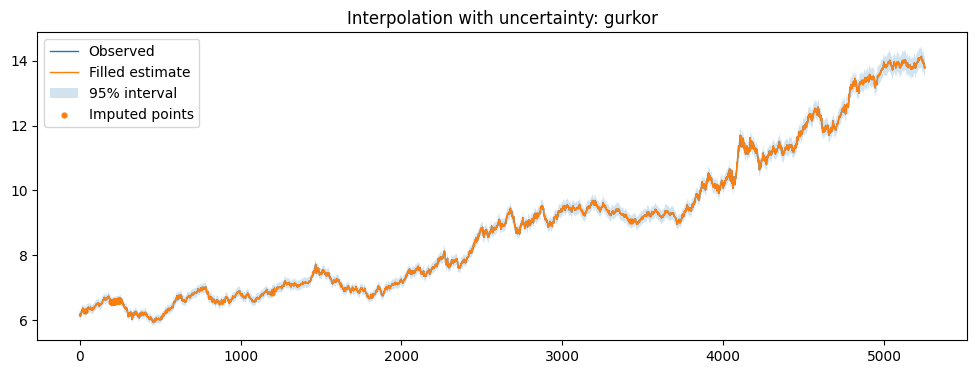

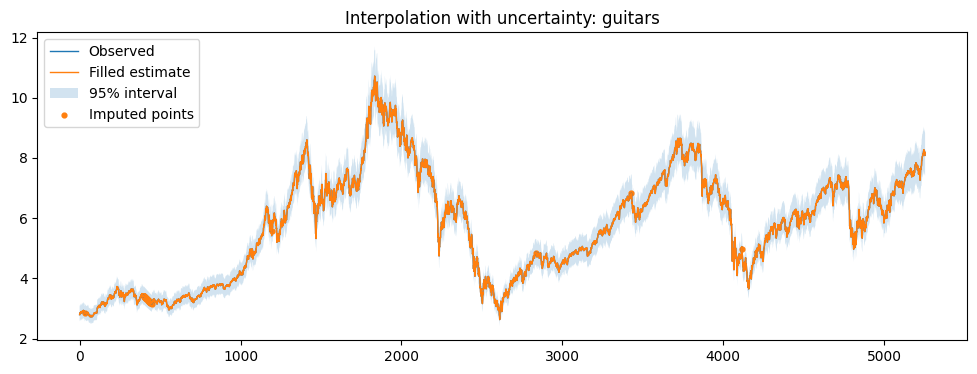

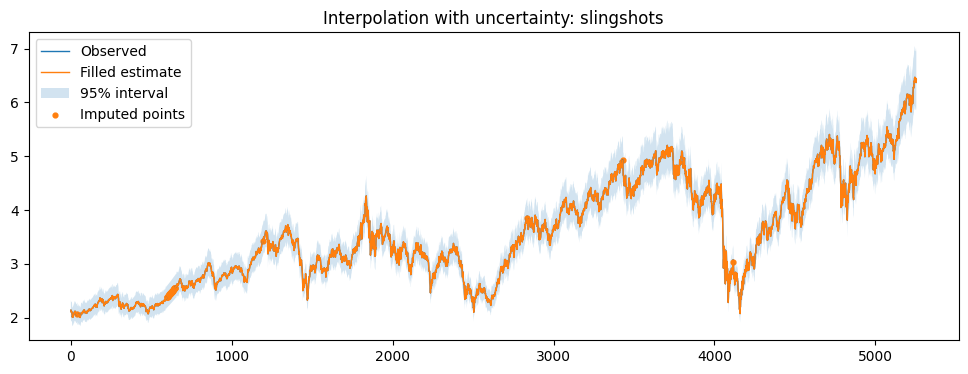

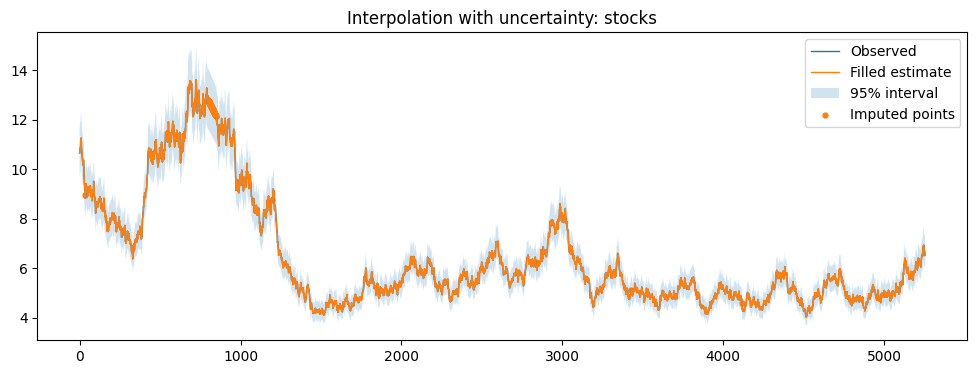

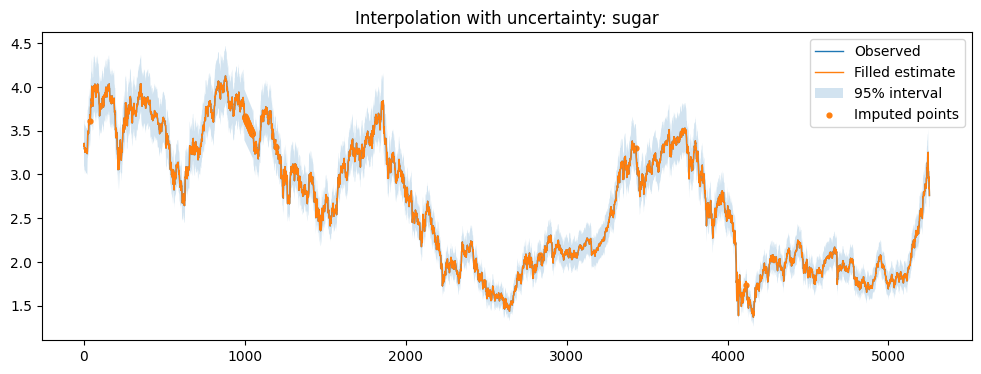

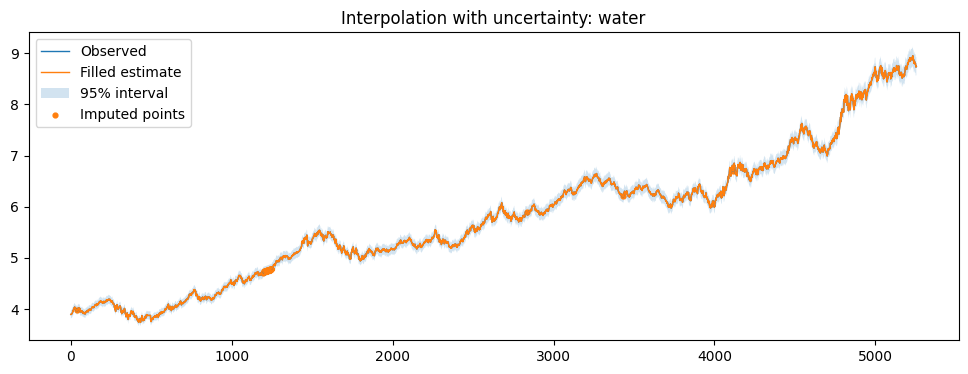

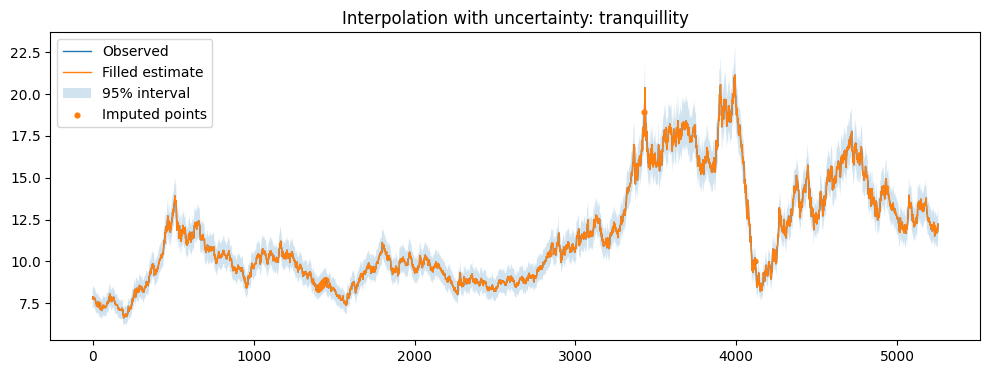

In [ ]:
def plot_interpolation(asset):
    original = df[asset].astype(float)
    est = intervals[asset].reindex(original.index)
    filled = est["estimate"]
    lower = est["lower_95"]
    upper = est["upper_95"]

    missing = original.isna().to_numpy()
    idx = original.index.to_numpy()

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(idx, original, label="Observed", linewidth=1)
    ax.plot(idx, filled, label="Filled estimate", linewidth=1)
    ax.fill_between(idx, lower, upper, alpha=0.2, label="95% interval")
    ax.scatter(idx[missing], filled.to_numpy()[missing], s=12, label="Imputed points")

    ax.set_title(f"Interpolation with uncertainty: {asset}")
    ax.legend()
    plt.show()


for asset in assets:
    plot_interpolation(asset)
